<a href="https://colab.research.google.com/github/Pranshu244/Urban-Flooding-Hydrology-Engine/blob/main/Data_Preparation/Hydrology_Engine_GIS_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rasterio

In [2]:
!pip install earthengine-api geemap

In [3]:
!rm -rf ~/.config/earthengine

In [4]:
!pip install netCDF4

In [5]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import plotting_extent
from rasterio.transform import rowcol
from rasterio.features import rasterize
import geopandas as gpd
from PIL import Image
import geemap
from scipy.ndimage import uniform_filter
from scipy.spatial import cKDTree
ds=nc.Dataset('RF25_ind2025_rfp25.nc')

In [6]:
file_path = 'RF25_ind2025_rfp25.nc'

In [7]:
print(ds.variables.items())

dict_items([('LONGITUDE', <class 'netCDF4.Variable'>
float64 LONGITUDE(LONGITUDE)
    units: degrees_east
    point_spacing: even
    axis: X
    modulo: 360.0
    standard_name: longitude
unlimited dimensions: 
current shape = (135,)
filling on, default _FillValue of 9.969209968386869e+36 used), ('LATITUDE', <class 'netCDF4.Variable'>
float64 LATITUDE(LATITUDE)
    units: degrees_north
    point_spacing: even
    axis: Y
    standard_name: latitude
unlimited dimensions: 
current shape = (129,)
filling on, default _FillValue of 9.969209968386869e+36 used), ('TIME', <class 'netCDF4.Variable'>
float64 TIME(TIME)
    units: days since 1900-12-31 00:00:00
    axis: T
    time_origin: 31-DEC-1900
    standard_name: time
unlimited dimensions: TIME
current shape = (365,)
filling on, default _FillValue of 9.969209968386869e+36 used), ('RAINFALL', <class 'netCDF4.Variable'>
float32 RAINFALL(TIME, LATITUDE, LONGITUDE)
    missing_value: -999.0
    _FillValue: -999.0
    long_name: Rainfall
    u

In [8]:
lats = ds.variables['LATITUDE'][:]
lons = ds.variables['LONGITUDE'][:]
time = ds.variables['TIME'][:]
rain = ds.variables['RAINFALL'][:]

In [9]:
rain.shape

(365, 129, 135)

In [10]:
lat_idx = np.where((lats >= 28.4) & (lats <= 28.9))[0]
lon_idx = np.where((lons >= 76.8) & (lons <= 77.35))[0]

In [11]:
delhi_rain = rain[:, lat_idx[:, None], lon_idx]
delhi_rain.shape

(365, 2, 2)

In [12]:
records = []
for t in range(len(time)):
    for i in lat_idx:
        for j in lon_idx:
            val = rain[t, i, j]
            if val != -999:
                records.append({
                    "day": t,
                    "lat": lats[i],
                    "lon": lons[j],
                    "rainfall_mm": val
                })

df = pd.DataFrame(records)
df.head()

,day,lat,lon,rainfall_mm
0,0,28.50,77.00,0.0
1,0,28.50,77.25,0.0
2,0,28.75,77.00,0.0
3,0,28.75,77.25,0.0
4,1,28.50,77.00,0.0


In [13]:
df.tail()

,day,lat,lon,rainfall_mm
1455,363,28.75,77.25,0.0
1456,364,28.50,77.00,0.0
1457,364,28.50,77.25,0.0
1458,364,28.75,77.00,0.0
1459,364,28.75,77.25,0.0


In [14]:
df.shape

(1460, 4)

In [15]:
df.describe()

,day,lat,lon,rainfall_mm
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,182.000000,28.625000,77.125000,2.164789
std,105.402131,0.125043,0.125043,6.992517
min,0.000000,28.500000,77.000000,0.000000
25%,91.000000,28.500000,77.000000,0.000000
50%,182.000000,28.625000,77.125000,0.000000
75%,273.000000,28.750000,77.250000,0.109304
max,364.000000,28.750000,77.250000,70.065666


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          1460 non-null   int64  
 1   lat          1460 non-null   float64
 2   lon          1460 non-null   float64
 3   rainfall_mm  1460 non-null   float32
dtypes: float32(1), float64(2), int64(1)
memory usage: 40.1 KB


In [17]:
df.select_dtypes(include='number').columns

Index(['day', 'lat', 'lon', 'rainfall_mm'], dtype='object')

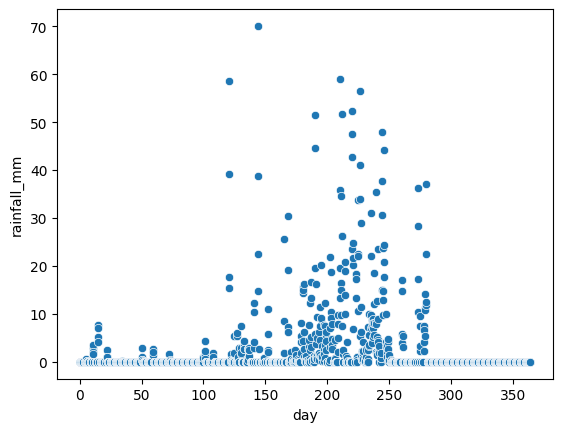

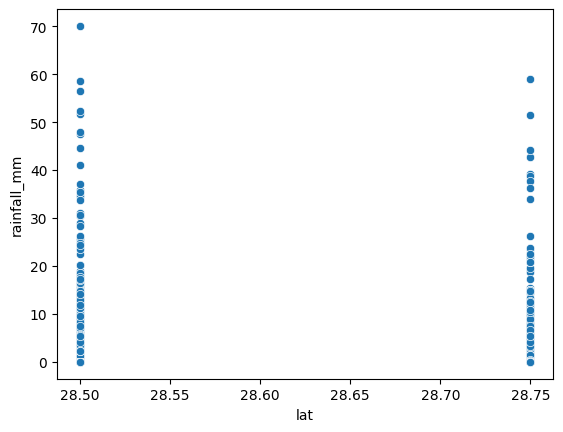

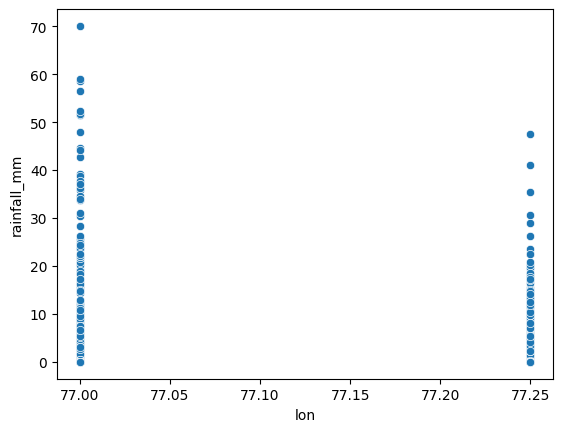

In [18]:
for i in ['day', 'lat', 'lon']:
  sns.scatterplot(data=df,x=i,y='rainfall_mm')
  plt.show()

In [19]:
import ee
ee.Authenticate(force=True)

In [20]:
ee.Initialize(project='YOUR PROJECT NAME')
print("Earth Engine READY")

Earth Engine READY


In [21]:
admin = ee.FeatureCollection("FAO/GAUL/2015/level2")
delhi = admin.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Delhi')
    )
)
print(delhi.size().getInfo())

1


In [22]:
dem = ee.Image("USGS/SRTMGL1_003")

In [23]:
delhi_dem = dem.clip(delhi)

In [24]:
stats = delhi_dem.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=delhi.geometry(),
    scale=30,
    maxPixels=1e9
)
print(stats.getInfo())

{'elevation_max': 313, 'elevation_min': 171}


In [25]:
task = ee.batch.Export.image.toDrive(
    image=delhi_dem,
    description='Delhi_DEM_30m',
    folder='GEE_Flood_Project',
    fileNamePrefix='delhi_dem_30m',
    region=delhi.geometry(),
    scale=30,
    maxPixels=1e13
)
task.start()
print("Export started")

Export started


In [26]:
task.status()

{'state': 'READY',
 'description': 'Delhi_DEM_30m',
 'priority': 100,
 'creation_timestamp_ms': 1772836928546,
 'update_timestamp_ms': 1772836928546,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_IMAGE',
 'id': '22FIKCBPNRABCZBC7343RVUB',
 'name': 'projects/ee-srivastavapranshu666/operations/22FIKCBPNRABCZBC7343RVUB'}

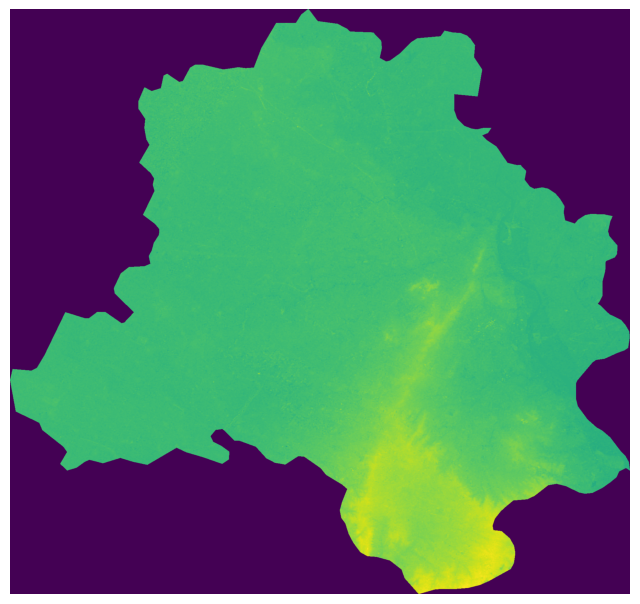

In [27]:
img = Image.open('delhi_dem_30m.tif')
img_array = np.array(img)

plt.figure(figsize=(8,8))
plt.imshow(img_array)
plt.axis('off')
plt.show()


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          1460 non-null   int64  
 1   lat          1460 non-null   float64
 2   lon          1460 non-null   float64
 3   rainfall_mm  1460 non-null   float32
dtypes: float32(1), float64(2), int64(1)
memory usage: 40.1 KB


In [29]:
with rasterio.open("delhi_dem_30m.tif") as src:
    dem = src.read(1).astype(float)
    transform = src.transform
    dem_shape = dem.shape
dem[dem == 0] = np.nan

In [30]:
rows, cols = dem.shape
xs, ys = np.meshgrid(np.arange(cols), np.arange(rows))
lons, lats = rasterio.transform.xy(transform, ys, xs)

In [31]:
dem_df = pd.DataFrame({
    "lat": np.array(lats).ravel(),
    "lon": np.array(lons).ravel(),
    "elevation_m": dem.ravel()
})
dem_df = dem_df.dropna().reset_index(drop=True)

print("DEM DF shape:", dem_df.shape)

DEM DF shape: (1913317, 3)


In [32]:
dem_df.describe()

,lat,lon,elevation_m
count,1.913317e+06,1.913317e+06,1.913317e+06
mean,2.864651e+01,7.710896e+01,2.216507e+02
std,1.078974e-01,1.138555e-01,1.807152e+01
min,2.840850e+01,7.683292e+01,1.710000e+02
25%,2.856211e+01,7.702075e+01,2.120000e+02
50%,2.863784e+01,7.711750e+01,2.150000e+02
75%,2.873028e+01,7.719727e+01,2.220000e+02
max,2.888443e+01,7.733768e+01,3.130000e+02


In [33]:
df.describe()

,day,lat,lon,rainfall_mm
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,182.000000,28.625000,77.125000,2.164789
std,105.402131,0.125043,0.125043,6.992517
min,0.000000,28.500000,77.000000,0.000000
25%,91.000000,28.500000,77.000000,0.000000
50%,182.000000,28.625000,77.125000,0.000000
75%,273.000000,28.750000,77.250000,0.109304
max,364.000000,28.750000,77.250000,70.065666


In [34]:
np.unique(dem[:1000])

array([180., 181., 184., 185., 186., 187., 188., 189., 190., 191., 192.,
       193., 194., 195., 196., 197., 198., 199., 200., 201., 202., 203.,
       204., 205., 206., 207., 208., 209., 210., 211., 212., 213., 214.,
       215., 216., 217., 218., 219., 220., 221., 222., 223., 224., 225.,
       226., 227., 228., 229., 230., 231., 232., 233., 234., 235., 236.,
       237., 238., 239., 240., 241., 242., 243., 244., 245., 246., 247.,
       248., 249., 250., 251., 252., 253., 254., 255., 256., 257., 258.,
       259., 260., 261., 262., 263., 264., 265., 266., 268., 271., 272.,
       278., 279.,  nan])

In [35]:
dem_df.shape

(1913317, 3)

In [36]:
rain_agg = df.groupby(["lat", "lon"])["rainfall_mm"].max().reset_index()
rain_agg.rename(columns={"rainfall_mm": "max_rainfall_mm"}, inplace=True)
print(rain_agg)

     lat    lon  max_rainfall_mm
0  28.50  77.00        70.065666
1  28.50  77.25        47.588989
2  28.75  77.00        59.042080
3  28.75  77.25        23.578249


In [37]:
rain_spatial = (
    df
    .groupby(["lat", "lon"])["rainfall_mm"]
    .quantile(0.95)
    .reset_index()
    .rename(columns={"rainfall_mm": "rain_95p_mm"})
)
print(rain_spatial)

     lat    lon  rain_95p_mm
0  28.50  77.00    19.924891
1  28.50  77.25    13.391333
2  28.75  77.00    18.516111
3  28.75  77.25     8.075898


In [38]:
rain_coords = rain_spatial[["lat", "lon"]].values
tree = cKDTree(rain_coords)

dem_coords = dem_df[["lat", "lon"]].values
_, idx = tree.query(dem_coords, k=1)

dem_df["rain_95p_mm"] = rain_spatial.iloc[idx]["rain_95p_mm"].values

In [39]:
dem_df[["elevation_m", "rain_95p_mm"]].describe()

,elevation_m,rain_95p_mm
count,1.913317e+06,1.913317e+06
mean,2.216507e+02,1.512571e+01
std,1.807152e+01,4.577235e+00
min,1.710000e+02,8.075898e+00
25%,2.120000e+02,1.339133e+01
50%,2.150000e+02,1.851611e+01
75%,2.220000e+02,1.851611e+01
max,3.130000e+02,1.992489e+01


In [40]:
dem_df.isnull().sum()

,0
lat,0
lon,0
elevation_m,0
rain_95p_mm,0


In [41]:
dem_df.head()

,lat,lon,elevation_m,rain_95p_mm
0,28.884429,77.075732,216.0,18.516111
1,28.884429,77.076001,216.0,18.516111
2,28.884159,77.075193,217.0,18.516111
3,28.884159,77.075462,216.0,18.516111
4,28.884159,77.075732,216.0,18.516111


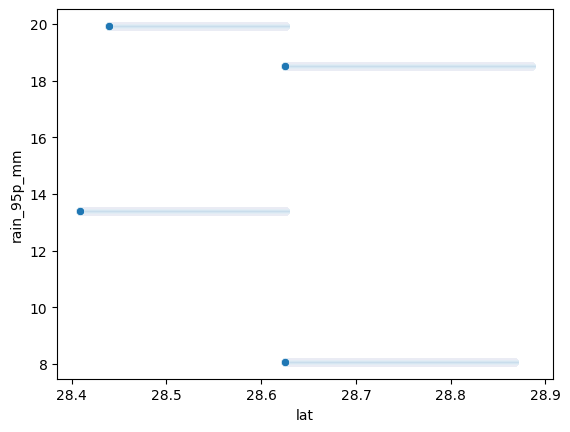

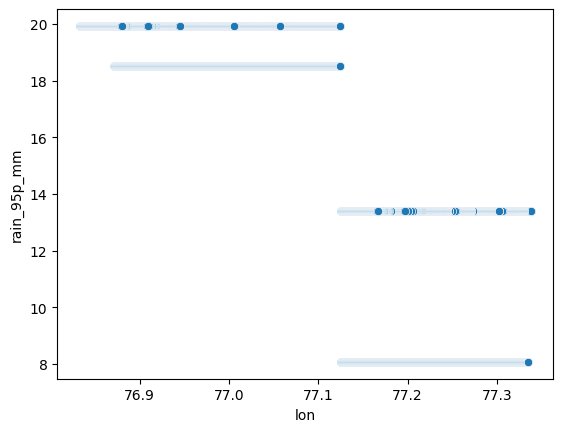

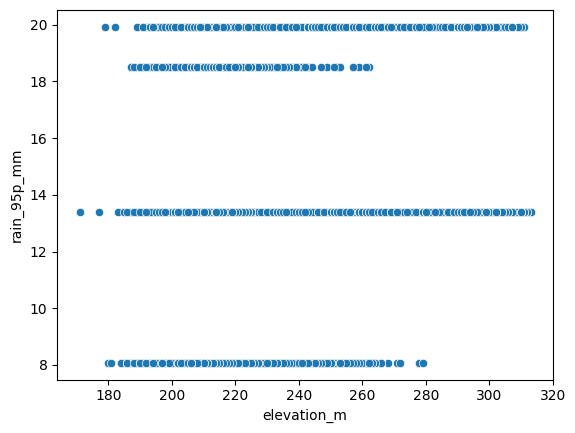

In [42]:
for i in ['lat', 'lon', 'elevation_m']:
  sns.scatterplot(data=dem_df,x=i,y='rain_95p_mm')
  plt.show()

In [43]:
dem_df.describe()

,lat,lon,elevation_m,rain_95p_mm
count,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06
mean,2.864651e+01,7.710896e+01,2.216507e+02,1.512571e+01
std,1.078974e-01,1.138555e-01,1.807152e+01,4.577235e+00
min,2.840850e+01,7.683292e+01,1.710000e+02,8.075898e+00
25%,2.856211e+01,7.702075e+01,2.120000e+02,1.339133e+01
50%,2.863784e+01,7.711750e+01,2.150000e+02,1.851611e+01
75%,2.873028e+01,7.719727e+01,2.220000e+02,1.851611e+01
max,2.888443e+01,7.733768e+01,3.130000e+02,1.992489e+01


In [44]:
dem_df.shape

(1913317, 4)

In [45]:
drains = gpd.read_file("export.geojson")
drains = drains[drains.geometry.notnull()]
drains = drains[drains.geometry.type == "LineString"]
print(drains.geometry.type.value_counts())

LineString    1285
Name: count, dtype: int64


In [46]:
drains = drains[drains.geometry.type == "LineString"]
print(len(drains))

1285


In [47]:
print(drains.crs)

EPSG:4326


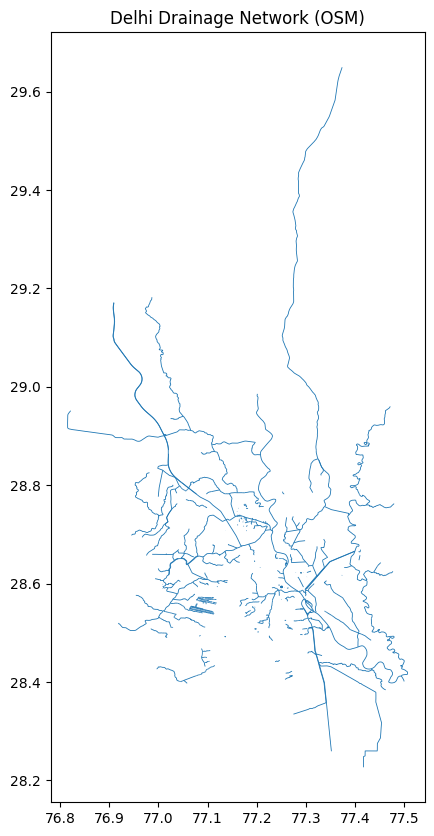

In [48]:
ax = drains.plot(figsize=(6,10), linewidth=0.6)
ax.set_aspect('equal')
plt.title("Delhi Drainage Network (OSM)")
plt.show()

In [49]:
drain_raster = rasterize(
    [(geom, 1) for geom in drains.geometry],
    out_shape=dem_shape,
    transform=transform,
    fill=0,
    dtype=np.uint8
)

In [50]:
print("Drain pixels:", drain_raster.sum())
print("Total pixels:", drain_raster.size)

Drain pixels: 25178
Total pixels: 3311358


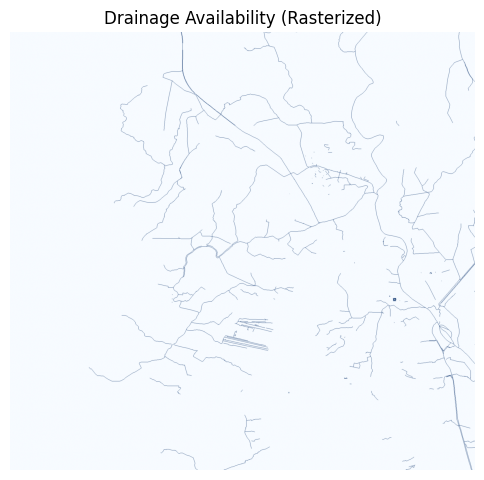

In [51]:
plt.figure(figsize=(6,10))
plt.imshow(drain_raster, cmap="Blues")
plt.title("Drainage Availability (Rasterized)")
plt.axis("off")
plt.show()

In [52]:
drain_flat = drain_raster.ravel()
valid_mask = ~np.isnan(dem.ravel())
drain_flat_valid = drain_flat[valid_mask]
dem_df["drain_present"] = drain_flat_valid

In [53]:
print(dem_df.shape)
print(dem_df.isna().sum())
print(dem_df.describe())
print(dem_df["drain_present"].value_counts())

(1913317, 5)
lat              0
lon              0
elevation_m      0
rain_95p_mm      0
drain_present    0
dtype: int64
                lat           lon   elevation_m   rain_95p_mm  drain_present
count  1.913317e+06  1.913317e+06  1.913317e+06  1.913317e+06   1.913317e+06
mean   2.864651e+01  7.710896e+01  2.216507e+02  1.512571e+01   1.031768e-02
std    1.078974e-01  1.138555e-01  1.807152e+01  4.577235e+00   1.010507e-01
min    2.840850e+01  7.683292e+01  1.710000e+02  8.075898e+00   0.000000e+00
25%    2.856211e+01  7.702075e+01  2.120000e+02  1.339133e+01   0.000000e+00
50%    2.863784e+01  7.711750e+01  2.150000e+02  1.851611e+01   0.000000e+00
75%    2.873028e+01  7.719727e+01  2.220000e+02  1.851611e+01   0.000000e+00
max    2.888443e+01  7.733768e+01  3.130000e+02  1.992489e+01   1.000000e+00
drain_present
0    1893576
1      19741
Name: count, dtype: int64


In [54]:
dem_df["drain_present"].value_counts()

,count
drain_present,
0,1893576
1,19741


In [55]:
dem_df.describe()

,lat,lon,elevation_m,rain_95p_mm,drain_present
count,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06
mean,2.864651e+01,7.710896e+01,2.216507e+02,1.512571e+01,1.031768e-02
std,1.078974e-01,1.138555e-01,1.807152e+01,4.577235e+00,1.010507e-01
min,2.840850e+01,7.683292e+01,1.710000e+02,8.075898e+00,0.000000e+00
25%,2.856211e+01,7.702075e+01,2.120000e+02,1.339133e+01,0.000000e+00
50%,2.863784e+01,7.711750e+01,2.150000e+02,1.851611e+01,0.000000e+00
75%,2.873028e+01,7.719727e+01,2.220000e+02,1.851611e+01,0.000000e+00
max,2.888443e+01,7.733768e+01,3.130000e+02,1.992489e+01,1.000000e+00


In [56]:
dem_df.sample(5)

,lat,lon,elevation_m,rain_95p_mm,drain_present
597214,28.705754,77.217486,213.0,8.075898,0
628023,28.699556,77.095674,216.0,18.516111,0
92675,28.829721,77.188111,208.0,8.075898,0
484375,28.728930,77.174906,210.0,8.075898,0
715577,28.682577,76.948530,216.0,18.516111,0


In [57]:
window_size = 9
drain_density = uniform_filter(
    drain_raster.astype(np.float32),
    size=window_size,
    mode="constant",
    cval=0.0
) * (window_size * window_size)

In [58]:
print("Drain density stats:")
print("Min:", drain_density.min())
print("Max:", drain_density.max())
print("Mean:", drain_density.mean())
print("Median:", np.median(drain_density))

Drain density stats:
Min: 0.0
Max: 60.000004
Mean: 0.61428213
Median: 0.0


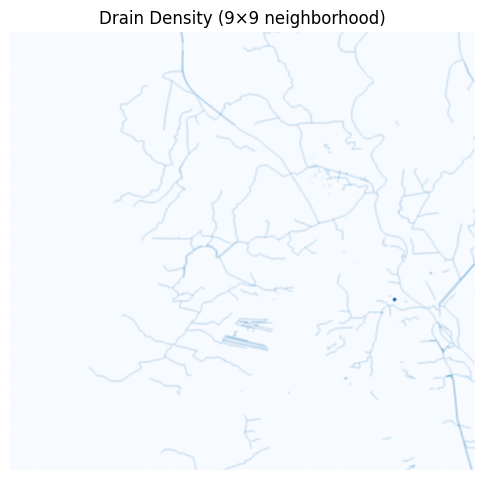

In [59]:
plt.figure(figsize=(6,10))
plt.imshow(drain_density, cmap="Blues")
plt.title("Drain Density (9×9 neighborhood)")
plt.axis("off")
plt.show()

In [60]:
drain_density_flat = drain_density.ravel()
valid_mask = ~np.isnan(dem.ravel())

In [61]:
drain_density_valid = drain_density_flat[valid_mask]

In [62]:
dem_df["drain_density"] = drain_density_valid

In [63]:
dem_df[["drain_present", "drain_density"]].describe()

,drain_present,drain_density
count,1.913317e+06,1.913317e+06
mean,1.031768e-02,8.362028e-01
std,1.010507e-01,2.705741e+00
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,1.000000e+00,6.000000e+01


In [64]:
dem_df["drain_density"].value_counts().head()

,count
drain_density,
0.0,1695973
9.0,74895
1.0,14302
2.0,14252
3.0,14064


In [65]:
dem_df.describe()

,lat,lon,elevation_m,rain_95p_mm,drain_present,drain_density
count,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06
mean,2.864651e+01,7.710896e+01,2.216507e+02,1.512571e+01,1.031768e-02,8.362028e-01
std,1.078974e-01,1.138555e-01,1.807152e+01,4.577235e+00,1.010507e-01,2.705741e+00
min,2.840850e+01,7.683292e+01,1.710000e+02,8.075898e+00,0.000000e+00,0.000000e+00
25%,2.856211e+01,7.702075e+01,2.120000e+02,1.339133e+01,0.000000e+00,0.000000e+00
50%,2.863784e+01,7.711750e+01,2.150000e+02,1.851611e+01,0.000000e+00,0.000000e+00
75%,2.873028e+01,7.719727e+01,2.220000e+02,1.851611e+01,0.000000e+00,0.000000e+00
max,2.888443e+01,7.733768e+01,3.130000e+02,1.992489e+01,1.000000e+00,6.000000e+01


In [66]:
final_cols = [
    "lat",
    "lon",
    "elevation_m",
    "rain_95p_mm",
    "drain_present",
    "drain_density"
]
hydrology_df = dem_df[final_cols].copy()
hydrology_df["drain_present"] = hydrology_df["drain_present"].astype("uint8")
output_path = "Hydrology_Engine_training.csv"
hydrology_df.to_csv(output_path, index=False)
print("✅ Dataset saved as:", output_path)
print("Shape:", hydrology_df.shape)
hydrology_df.head()

✅ Dataset saved as: Hydrology_Engine_training.csv
Shape: (1913317, 6)


,lat,lon,elevation_m,rain_95p_mm,drain_present,drain_density
0,28.884429,77.075732,216.0,18.516111,0,0.0
1,28.884429,77.076001,216.0,18.516111,0,0.0
2,28.884159,77.075193,217.0,18.516111,0,0.0
3,28.884159,77.075462,216.0,18.516111,0,0.0
4,28.884159,77.075732,216.0,18.516111,0,0.0


In [67]:
delhi = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM2_NAME', 'Delhi'))
s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .select('VH')
                 .filterBounds(delhi))
before = s1_collection.filterDate('2023-07-01', '2023-07-07').mosaic().clip(delhi)
after = s1_collection.filterDate('2023-07-10', '2023-07-15').mosaic().clip(delhi)
flood_diff = after.subtract(before)
flood_mask = flood_diff.lt(-3).rename('flood_actual')
Map = geemap.Map()
Map.centerObject(delhi, 11)
Map.addLayer(before, {'min': -25, 'max': 0}, 'Pre-Flood (July 1)')
Map.addLayer(after, {'min': -25, 'max': 0}, 'Peak-Flood (July 13)')
Map.addLayer(flood_mask.selfMask(), {'palette': 'red'}, 'Sentinel-1 Actual Flood 2023')
Map

Map(center=[28.646455931994893, 77.10900424302302], controls=(WidgetControl(options=['position', 'transparent_…

In [68]:
task = ee.batch.Export.image.toDrive(
    image=flood_mask,
    description='Delhi_Actual_Flood_2023',
    scale=30,
    region=delhi.geometry(),
    fileFormat='GeoTIFF'
)
task.start()